## Molecule Search

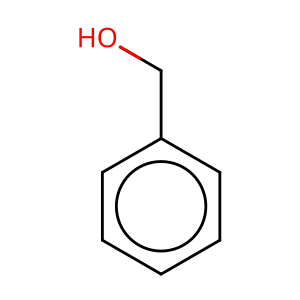

In [2]:
from chemaxon.io import import_mol
from chemaxon.search import MoleculeSearch, SearchType
from chemaxon.standardizer import Standardizer

query = import_mol('C1=CC=CC=C1')
target = import_mol('OCc1ccccc1')
target

### **Hit indices**

In [4]:
substructure_search = MoleculeSearch()
hit = substructure_search.find(query, target)
hit.hit_indices

[2, 3, 4, 5, 6, 7]

### **Duplicate search, setting search options**

**Note:** In case of duplicate search, the used tautomerization mode is **_generic_**. Which means, that all the theoretically possible tautomers of the target  is matched with the query structure itself.

In [6]:
duplicate_search = MoleculeSearch(search_type=SearchType.DUPLICATE)
hit = duplicate_search.find(query, target)
hit is None

True

### **Hit coloring**

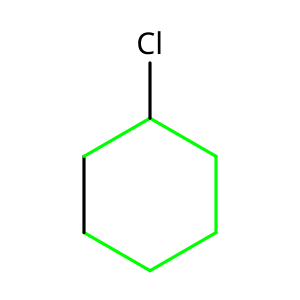

In [7]:
q = import_mol('CCCCCC')
t = import_mol('C1CCCCC1Cl')
MoleculeSearch().find(q, t, return_colored_hit=True).colored_hit

### **Setting standardizer**

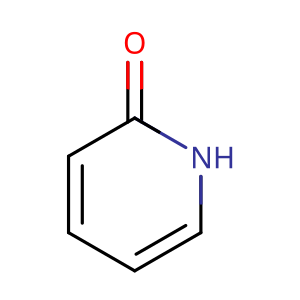

In [8]:
basic_arom_search = MoleculeSearch(standardizer=Standardizer('aromatize:b'))
q_basic = import_mol('CC')
t_basic = import_mol('O=C1NC=CC=C1')
t_basic

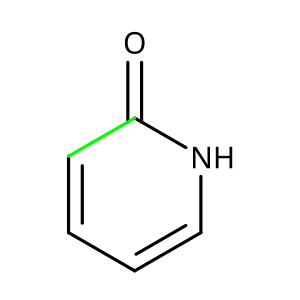

In [9]:
basic_arom_search.find(q_basic,t_basic, return_colored_hit=True).colored_hit

### **No standardizer**

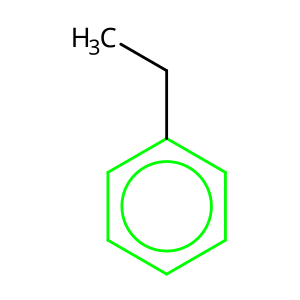

In [10]:
search_no_st = MoleculeSearch(standardizer="")
search_no_st.find(import_mol('c1ccccc1'), import_mol('c1ccccc1CC'), True).colored_hit

In [31]:
search_no_st = MoleculeSearch(standardizer=None)
search_no_st.find(import_mol('c1ccccc1'), import_mol('C1=CC=CC=C1'), True) is None

True

### **Bulk Search**

In [11]:
bulk_search = MoleculeSearch()

query = import_mol('C1=CC=CC=C1')
targets = [import_mol('OCc1ccccc1'), import_mol('CC'), import_mol('c1ccccc1')]
hits = bulk_search.find_in_list(query, targets)
hits

[SearchHit(hit_indices=[2, 3, 4, 5, 6, 7], colored_hit=None),
 None,
 SearchHit(hit_indices=[0, 1, 2, 3, 4, 5], colored_hit=None)]

In [12]:
[hit.hit_indices if hit is not None else hit for hit in hits]

[[2, 3, 4, 5, 6, 7], None, [0, 1, 2, 3, 4, 5]]

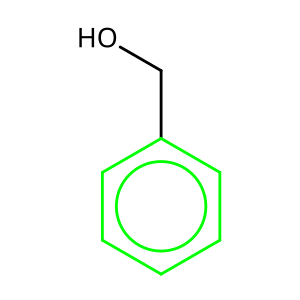

In [13]:
from chemaxon.io import export_mol
colored_hits = bulk_search.find_in_list(query, targets, return_colored_hit=True)
colored_hits[0].colored_hit

### **Bulk search speed**

In [14]:
import time 
start = time.time()
hits = bulk_search.find_in_list(query, targets*5000)
time.time()-start

0.8804423809051514

In [15]:
substructure_search = MoleculeSearch()
start = time.time()
hits = [substructure_search.find(query, t) for  t in targets*5000 ]
time.time()-start

4.3208136558532715

### **Find all hits**

`find_all` returns every distinct mapping of the query onto the target (including symmetry-equivalent ones), unlike `find`, which stops at the first hit.

Number of hits: 2
Hit indices:  [[0, 1, 2, 3, 8, 9], [3, 4, 5, 6, 7, 8]]


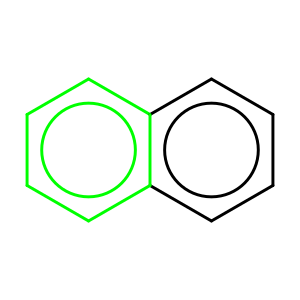

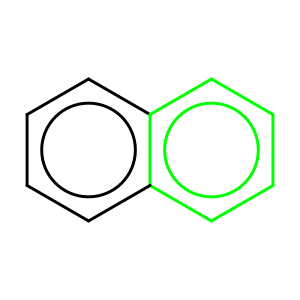

In [11]:
from chemaxon.io import import_mol
from chemaxon.search import MoleculeSearch

query = import_mol('c1ccccc1')
target = import_mol('c1ccc2ccccc2c1')  # naphthalene: two fused benzene rings

all_hits = MoleculeSearch().find_all(query, target, True)
print('Number of hits:', len(all_hits))
print('Hit indices: ', [hit.hit_indices for hit in all_hits])
for hit in all_hits:
    display(hit.colored_hit)

The `limit` parameter caps the number of hits collected, which is useful when only a bounded number of matches is needed:

In [4]:
limited_hits = MoleculeSearch().find_all(query, target, limit=1)
len(limited_hits)

1